In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv('Placement_Data_Full_Class.csv')

In [3]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [4]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [5]:
#1)Replace the NaN values with correct value. And justify why you have chosen the same.
#In a dataset, NaN values will break analysis, reduce accuracy, and cause errors in models and to overcome this we check the dataset and analyze
#the NAN column, In this dataset we found whichever students not placed will not get salary,so that particular row value shows nan.
#we can replace missing value from NAN to 0, so that the dataset will not return NAN value and we can acheive our best model.

In [15]:
dataset['salary']=dataset['salary'].fillna(0)

In [16]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [17]:
dataset.columns

Index(['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s',
       'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p',
       'status', 'salary'],
      dtype='str')

In [6]:
for columnname in dataset.columns:
    print(columnname)

sl_no
gender
ssc_p
ssc_b
hsc_p
hsc_b
hsc_s
degree_p
degree_t
workex
etest_p
specialisation
mba_p
status
salary


In [7]:
#How many of them are not placed? 67 (39 Male and 28 Female not placed)
#((dataset['gender'] == 'M') & (dataset['status'] == 'Not Placed')).sum()
#((dataset['gender'] == 'F') & (dataset['status'] == 'Not Placed')).sum()
(dataset['status'] == 'Not Placed').sum()

np.int64(67)

In [ ]:
#3)Find the reason for non placement from the dataset?

In [8]:
dataset.groupby('status')['mba_p'].mean()

status
Not Placed    61.612836
Placed        62.579392
Name: mba_p, dtype: float64

In [ ]:
#4)What kind of relation between salary and mba_p
#positive correlation - salary and mba_p = 0.139823

In [9]:
dataset[['mba_p', 'salary']].corr()

,mba_p,salary
mba_p,1.000000,0.175013
salary,0.175013,1.000000


In [ ]:
#5)Which specialization is getting minimum salary?

In [10]:
dataset['salary'].min()

np.float64(200000.0)

In [11]:
dataset.groupby('specialisation')['salary'].min()

specialisation
Mkt&Fin    200000.0
Mkt&HR     200000.0
Name: salary, dtype: float64

In [ ]:
#How many of them getting above 500000 salary?

In [12]:
dataset[dataset['salary'] > 500000]

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
119,120,M,60.8,Central,68.40,Central,Commerce,64.6,Comm&Mgmt,Yes,82.66,Mkt&Fin,64.34,Placed,940000.0
150,151,M,71.0,Central,58.66,Central,Science,58.0,Sci&Tech,Yes,56.00,Mkt&Fin,61.30,Placed,690000.0
177,178,F,73.0,Central,97.00,Others,Commerce,79.0,Comm&Mgmt,Yes,89.00,Mkt&Fin,70.81,Placed,650000.0


In [13]:
(dataset['salary'] > 500000).sum()

np.int64(3)

In [ ]:
#Test the Analysis of Variance between etest_p and mba_p at signifance level 5%.
#(Make decision using Hypothesis Testing)

In [18]:
#one way classification
import scipy.stats as stats
stats.f_oneway(dataset['etest_p'],dataset['mba_p'])

F_onewayResult(statistic=np.float64(98.64487057324709), pvalue=np.float64(4.672547689133636e-21))

In [ ]:
# signifance level 5%. p-value < 0.05 reject null hypothesis
#As p-value is 4.67  < 0.05 - False
#As analzed the problem statement using ANOVA method and we observed p value is 4.67
#we accept null Hypothesis H0.
#Result is there is no sigificant difference on the dependent variable SSC_P

In [ ]:
#Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary at significance level of 5%.(Make
#decision using Hypothesis Testing)


In [19]:
from scipy.stats import ttest_ind
tech=dataset[dataset['degree_t']=='Sci&Tech']['salary']
tech1=dataset[dataset['specialisation']=='Mkt&HR']['salary']
ttest_ind(tech,tech1)


TtestResult(statistic=np.float64(2.692041243555374), pvalue=np.float64(0.007897969943471191), df=np.float64(152.0))

In [25]:
#p-value =0.05 , here p-value = 0.007 so, 0.007 < 0.05 true (reject null hypothesis & accept alternate hypothesis)
#H0 - reject null hypothesis
#H1 - accept alternate hypothesis
#"result is statistically significant"
#conclude that degree_p and specialisation significantly influence salary.

In [26]:
#Convert the normal distribution to standard normal distribution for salary column
#stdND - standard normal distribution
#we use Seaborn for plotting and Finds average salary mean / Calculate Standard Deviation / Converts dataset into a list
# using zscore = X−μ / σ formula (for each value subtract mean and divide by standard deviation)
# histplot - Histogram (bars) / KDE curve (smooth line)
# Return Mean of Z-scores - Calculates average of z-scores
# return sum(z_score)/len(z_score) - is calculating mean of Z-scores
# What your function does:
# it Standardizes data / Plots normal distribution / Returns mean of standardized values
# result = verifies that the transformed data has a mean approximately equal to zero.
#zcore = (-7.126082669687051e-17 ≈ 0) 

In [31]:
def stdNDgraph(dataset):
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()
    values=[i for i in dataset]
    z_score=[((k - mean)/std)for k in values]
    sns.histplot(z_score,kde=True)
    plt.title("Standard Normal Distribution of Salary")
    return sum(z_score)/len(z_score)
    #z_salary = zscore(dataset['salary'])

np.float64(-7.126082669687051e-17)

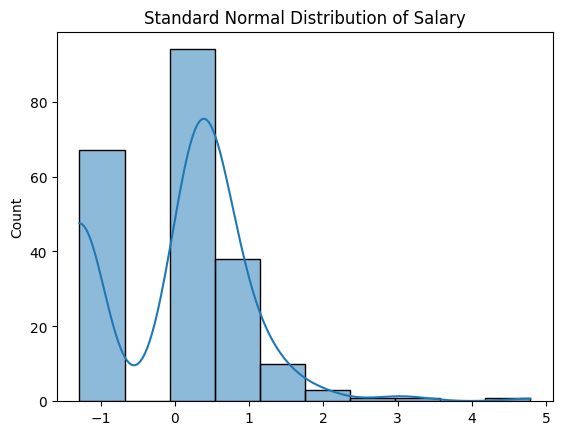

In [32]:
stdNDgraph(dataset['salary'])

#What is the probability Density Function of the salary range from 700000 to 900000?
PDF - tell about probability of particular range

In [33]:
#Probablity Density function = PDF
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    #kernel density function (kde) to get the curve
    sns.histplot(dataset, kde=True, color='green')
    #vline - vertical line
    plt.axvline(startrange,color='Red')
    plt.axvline(endrange,color='Red')
    #generate a sample
    sample = dataset
    #calculate parameters
    sample_mean = dataset.mean()  # Finds average of dataset
    sample_std = dataset.std()    # Calculate Standard Deviation
    #Prints values rounded to 3 decimals
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    #define the normal distribution, #norm from scipy.stats import norm
    dist=norm(sample_mean, sample_std)
    #sample probablity for a range of outcomes / Generates numbers between start and end
    values=[value for value in range(startrange,endrange)]
    #pdf is a function
    probabilities = [dist.pdf(value) for value in values]
    #summation / Adds all PDF values
    prob=sum(probabilities)
    print("The area between range ({},{}):{}".format(startrange,endrange,sum(probabilities)))
    #Returns total probability
    return prob

Mean=198702.326, Standard Deviation=154780.927
The area between range (700000,900000):0.0005973310593974868


np.float64(0.0005973310593974868)

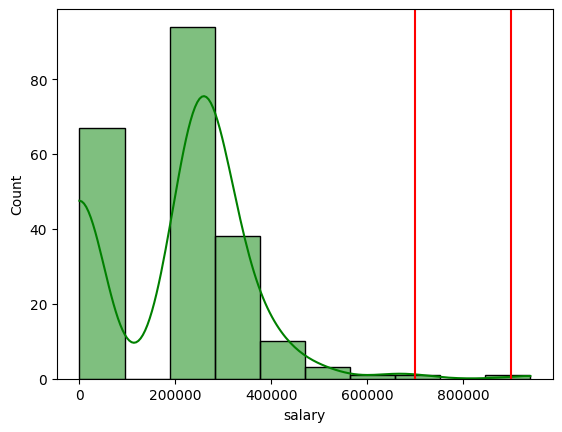

In [34]:
get_pdf_probability(dataset['salary'],700000,900000)

In [37]:
from scipy.stats import norm

mean = 198702.326
std = 154780.927

#defining a normal distribution
dist = norm(mean, std)

#This gives exact probability between two values
#calculate probabilty P(X ≤ value)
prob = dist.cdf(900000) - dist.cdf(700000)

print(prob)

0.0005973243242414217


In [38]:
#0.000597 ≈ 0.0597%
#Only 0.06% chance
#Extremely rare salaries in that range

#Test the similarity between the degree_t(Sci&Tech)with respect to etest_p and mba_p at significance level of 5%.
(Make decision using Hypothesis Testing)
We use paired T-test (Dependent Sample)
same group Sci&Tech but diffent condition etest_p and mba_p

In [39]:
from scipy.stats import ttest_rel
deg = dataset[dataset['degree_t']=='Sci&Tech']['etest_p']
deg1 = dataset[dataset['degree_t']=='Sci&Tech']['mba_p']
ttest_rel(deg,deg1)

TtestResult(statistic=np.float64(5.0049844583693615), pvalue=np.float64(5.5179206005054e-06), df=np.int64(58))

In [41]:
#p-value = 5.5179206005054 × 10⁻⁶ = 0.0000055179
# 5% = p -value < 0.05 so, 0.000005 < 0.05 = True
#H0 - reject null hypothesis
#H1 - accept alternate hypothesis
#"result is statistically significant"
##conclude that etest_p and mba_p significantly influence degree_t.

#Which parameter is highly correlated with salary?

In [44]:
dataset.drop('sl_no',inplace=True,axis=1)

In [45]:
dataset.corr(numeric_only=True)

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,1.000000,0.511472,0.538404,0.261993,0.388478,0.538090
hsc_p,0.511472,1.000000,0.434206,0.245113,0.354823,0.452569
degree_p,0.538404,0.434206,1.000000,0.224470,0.402364,0.408371
etest_p,0.261993,0.245113,0.224470,1.000000,0.218055,0.186988
mba_p,0.388478,0.354823,0.402364,0.218055,1.000000,0.139823
salary,0.538090,0.452569,0.408371,0.186988,0.139823,1.000000


In [47]:
#ssc_p has the highest correlation with salary (~0.54) Positive correlation , 54% directly proportional
#hsc_p & degree_p = moderately correlated
#etest_p & mba_p = Weak correlation

In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_vif(X):
    vif=pd.DataFrame()
    vif["variables"]=X.columns
    vif["VIF"]=[variance_inflation_factor(X.values,i) for i in range (X.shape[1])]
    return (vif)

In [57]:
calc_vif(dataset[['ssc_p', 'salary']]) # Moderately correlated (1~5) 3.24

,variables,VIF
0,ssc_p,3.248087
1,salary,3.248087


#plot any useful graph and explain it.

<Axes: xlabel='ssc_p', ylabel='Count'>

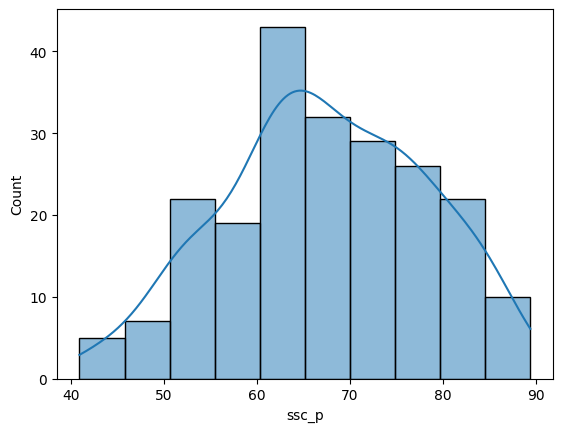

In [59]:
#normal distribution
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(dataset["ssc_p"], kde=True)

In [73]:
#When we get a bell curve, we say normally distributed
#standard deviation and mean plays an important role in normal distribution
# depends on allowance of error is standard deviation

In [61]:
#Probablity Density function = PDF
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    
    sns.histplot(dataset, kde=True, color='green')
   
    plt.axvline(startrange,color='Red')
    plt.axvline(endrange,color='Red')
    
    sample = dataset
   
    sample_mean = dataset.mean()  
    sample_std = dataset.std()   
  
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    
    dist=norm(sample_mean, sample_std)
    
    values=[value for value in range(startrange,endrange)]
  
    probabilities = [dist.pdf(value) for value in values]
    
    prob=sum(probabilities)
    
    print("The area between range ({},{}):{}".format(startrange,endrange,sum(probabilities)))
    
    return prob

Mean=67.303, Standard Deviation=10.827
The area between range (60,70):0.3449514151280293


np.float64(0.3449514151280293)

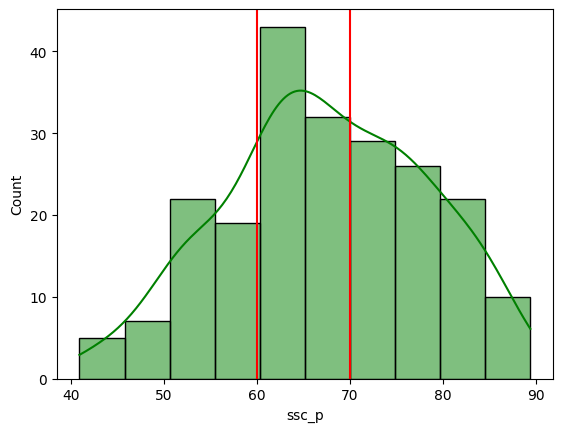

In [69]:
get_pdf_probability(dataset['ssc_p'],60,70)
#to get 60 to 70 pass mark - PDF 34% possible is there.
#to get 40 to 50 pass mark - PDF only 4% possible is there.
#to get 40 to 40 pass mark - 0%